In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

In [ ]:
# VAE MODEL

class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, z_dim):
        super(VAE, self).__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU()
        )

        self.mu = nn.Linear(hidden_dim, z_dim)
        self.logvar = nn.Linear(hidden_dim, z_dim)

        self.decoder = nn.Sequential(
            nn.Linear(z_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        mu = self.mu(h)
        logvar = self.logvar(h)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

    def decode(self, z):
        return self.decoder(z)

In [ ]:
# LOSS FUNCTION

def vae_loss(recon_x, x, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

In [ ]:
# TRAIN FUNCTION

def train_vae(loader, input_dim, z_dim, epochs):
    model = VAE(input_dim=input_dim, hidden_dim=512, z_dim=z_dim).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(epochs):
        total_loss = 0
        for data, _ in loader:
            data = data.to(device)
            data = data.view(data.size(0), -1)

            optimizer.zero_grad()
            recon, mu, logvar = model(data)

            # normalize loss
            loss = vae_loss(recon, data, mu, logvar) / data.size(0)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        #  better loss printing
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss / len(loader.dataset):.4f}")

    return model

In [ ]:
# GENERATE IMAGES

def generate_images(model, z_dim, img_shape, save_name, is_color=False):
    model.eval()

    z = torch.randn(16, z_dim).to(device)

    with torch.no_grad():
        generated = model.decode(z)

    generated = generated.view(-1, *img_shape).cpu()

    fig, axes = plt.subplots(4, 4, figsize=(6,6))

    for i, ax in enumerate(axes.flat):
        if is_color:
            img = generated[i].permute(1,2,0)
            ax.imshow(img.clamp(0,1))   #  stable visualization
        else:
            ax.imshow(generated[i][0], cmap='gray')
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(save_name)
    plt.show()

Using device: cpu

 TRAINING MNIST 
Epoch 1/10, Loss: 1.4703
Epoch 2/10, Loss: 1.3065
Epoch 3/10, Loss: 1.2761
Epoch 4/10, Loss: 1.2593
Epoch 5/10, Loss: 1.2472
Epoch 6/10, Loss: 1.2378
Epoch 7/10, Loss: 1.2291
Epoch 8/10, Loss: 1.2218
Epoch 9/10, Loss: 1.2153
Epoch 10/10, Loss: 1.2094


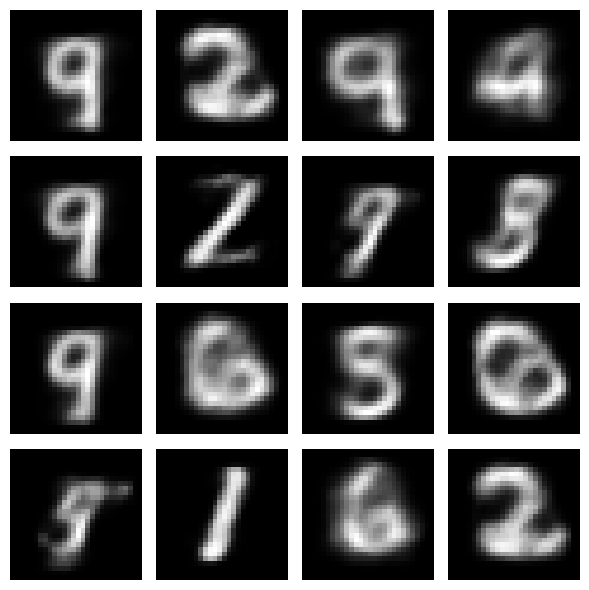


 TRAINING TINY-IMAGENET
Using path: C:\Users\vandn\Desktop\New folder\tiny-imagenet (1)\train
Epoch 1/5, Loss: 130.1511
Epoch 2/5, Loss: 124.5159
Epoch 3/5, Loss: 121.9759
Epoch 4/5, Loss: 120.3153
Epoch 5/5, Loss: 119.2593


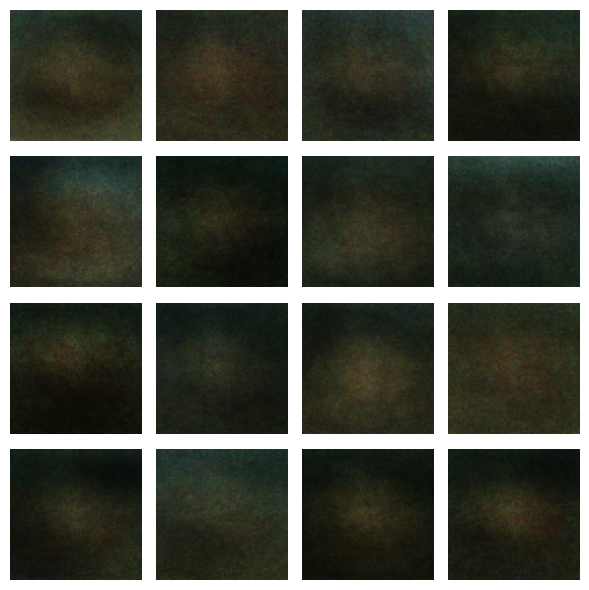

In [ ]:
#  MNIST
print("\n TRAINING MNIST ")

mnist_dataset = datasets.MNIST(
    root="MNIST_data",
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

mnist_loader = DataLoader(mnist_dataset, batch_size=128, shuffle=True)

mnist_model = train_vae(
    mnist_loader,
    input_dim=28*28,
    z_dim=2,
    epochs=10
)

# save model
torch.save(mnist_model.state_dict(), "vae_mnist.pth")

generate_images(
    mnist_model,
    z_dim=2,
    img_shape=(1,28,28),
    save_name="mnist_generated.png",
    is_color=False
)


# TINY-IMAGENET

print("\n TRAINING TINY-IMAGENET")

base_path = r"C:\Users\vandn\Desktop\New folder\tiny-imagenet (1)"

if os.path.exists(base_path + r"\tiny-imagenet-200\train"):
    tiny_path = base_path + r"\tiny-imagenet-200\train"
elif os.path.exists(base_path + r"\train"):
    tiny_path = base_path + r"\train"
else:
    raise Exception("Train folder not found")

print("Using path:", tiny_path)

tiny_dataset = datasets.ImageFolder(
    root=tiny_path,
    transform=transforms.Compose([
        transforms.Resize((64,64)),
        transforms.ToTensor()
    ])
)

tiny_loader = DataLoader(tiny_dataset, batch_size=64, shuffle=True)

tiny_model = train_vae(
    tiny_loader,
    input_dim=3*64*64,
    z_dim=128,
    epochs=5
)

# save model
torch.save(tiny_model.state_dict(), "vae_tiny.pth")

generate_images(
    tiny_model,
    z_dim=128,
    img_shape=(3,64,64),
    save_name="tiny_generated.png",
    is_color=True
)

